# Pazy wing deformed mode frequencies

Plot the evolution of the first 5 natural frequencies with varying displacement, where we control the displacement by changing the freestream velocity. Yields a plot akin to Fig. 10 in "Collaborative Pazy Wing Analyses for the Third Aeroelastic Prediction Workshop".

Imports

In [ ]:
import jax
from jax import Array
from jax import numpy as jnp
from matplotlib import pyplot as plt

from flapjax.aero.flowfields import ConstantFlowField
from flapjax.models.pazy.straight.pazy_wing import generate_pazy_wing
from flapjax.utils.print_utils import set_verbosity

Initial variables

In [ ]:
set_verbosity("silent")  # suppress console prints

Discretisation and sweep parameters. Dynamic pressure is swept linearly and converted to freestream velocity magnitude.

In [16]:
N_VEL = 256  # number of velocity cases to evaluate
BATCH_SIZE = 32  # number of velocity cases to evaluate at once

rho = 1.225  # freestream density
alpha = jnp.deg2rad(7.0)  # angle of attack

q_inf = jnp.linspace(1e-3, 2900.0, N_VEL)  # dynamic pressures
u_inf_mags = jnp.sqrt(q_inf * 2.0 / rho)  # velocity magnitudes corresponding to the dynamic pressures

Build the wing as the structural data is shared across all velocities.

In [ ]:
wing = generate_pazy_wing(
    flowfield=ConstantFlowField(
        u_inf=jnp.array([0.0, 0.0, 0.0]),  # whilst this is zero, we overwrite it for every instance
        rho=rho,
        relative_motion=True,
    ),
    aoa=alpha,
    m=12,
    m_star=40,
    node_multiplier=2,
    skin=True,
    variable_disc_wake=False,
    sweep=0.0,
)

Per-velocity solve. Swaps the freestream flowfield, obtains static equilibrium, and returns the mid-chord tip Z displacement together with the first 5 natural frequencies about that deformed state.

In [18]:
def modes_at_velocity(u_mag: Array) -> tuple[Array, Array]:
    # swap only the flowfield's u_inf
    wing.aero.flowfield = ConstantFlowField(
        u_inf=jnp.array([u_mag, 0.0, 0.0]),
        rho=rho,
        relative_motion=True,
    )
    # find deformation for clamped wing with horseshoe wake
    static_sol = wing.static_solve(
        prescribed_dofs=tuple(range(6)),
        horseshoe=True,
    )
    freqs_, *_ = wing.structure.modal(case=static_sol.structure,
                                      n_modes=5)  # evaluate natural frequencies of structure for given deformation

    tip_z_ = 0.5 * (
            static_sol.aero.zeta_b[0][0, -1, 2] + static_sol.aero.zeta_b[0][-1, -1, 2]
    )  # evaluate mid-chord tip deflection from the deformed aerodynamic grid zeta_b

    return tip_z_, freqs_

Run the sweep across all velocities using `jax.lax.map` with the configured batch size.

In [19]:
tip_z, freqs = jax.lax.map(modes_at_velocity, u_inf_mags, batch_size=BATCH_SIZE)

Plot mode frequency against tip displacement for each of the first 5 modes.

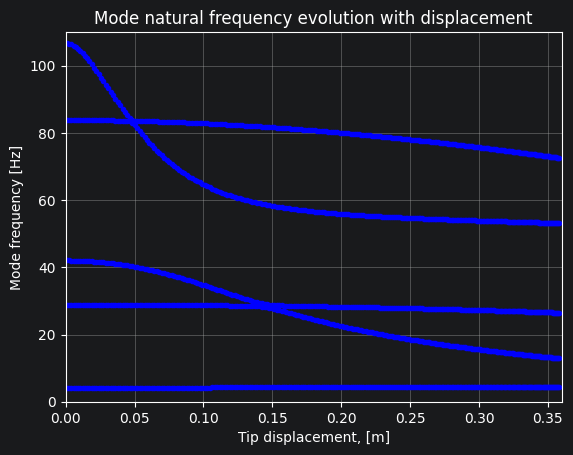

In [20]:
fig, ax = plt.subplots()
for i in range(N_VEL):
    ax.plot(jnp.broadcast_to(tip_z[i, None], (5,)), freqs[i, :], "b.")
ax.set_xlabel("Tip displacement, [m]")
ax.set_ylabel("Mode frequency [Hz]")
ax.set_title("Mode natural frequency evolution with displacement")
ax.set_xlim(0.0, 0.36)
ax.set_ylim(0.0, 110.0)
ax.grid(True)

plt.show()